In [3]:
import pandas as pd
import numpy as np



In [5]:
plasma_data = pd.read_excel('PR80_30/plasma_data_imputed_30.xlsx')
tissue_data = pd.read_excel('PR80_30/tissue_data_imputed_30.xlsx')


print(plasma_data.shape)
print(tissue_data.shape)

(1531, 53)
(6630, 53)


In [13]:
##### Plasma only
graph_plasma_400 = pd.read_csv('PR80_30/gene_edges_model_plasma_400.csv')
graph_plasma_700 = pd.read_csv('PR80_30/gene_edges_model_plasma_700.csv')
##### Tissue only
graph_tissue_400 = pd.read_csv('PR80_30/gene_edges_model_tissue_400.csv')
graph_tissue_700 = pd.read_csv('PR80_30/gene_edges_model_tissue_700.csv')

##### common only
graph_common_400 = pd.read_csv('PR80_30/gene_edges_model_common_400.csv')
graph_common_700 = pd.read_csv('PR80_30/gene_edges_model_common_700.csv')

##### Union
graph_union_400 = pd.read_csv('PR80_30/gene_edges_model_union_400.csv')
graph_union_700 = pd.read_csv('PR80_30/gene_edges_model_union_700.csv')

In [18]:
plasma_proteins = set(protein for protein in plasma_data['Genes'].values if protein in graph_genes)
tissue_proteins = set(protein for protein in tissue_data['Genes'].values if protein in graph_genes)

shared_proteins = set(protein for protein in tissue_proteins if protein in plasma_proteins)
plasma_only_proteins = plasma_proteins.difference(shared_proteins)
tissue_only_proteins = tissue_proteins.difference(shared_proteins)

print(f'Shared proteins: {len(shared_proteins)}')
print(f'Plasma only proteins: {len(plasma_only_proteins)}')
print(f'Tissue only proteins: {len(tissue_only_proteins)}')

Shared proteins: 1316
Plasma only proteins: 98
Tissue only proteins: 5145


In [19]:
import networkx as nx
def graph_stats(edges_400, edges_700):
    n_edges_400 = len(edges_400)
    n_edges_700 = len(edges_700)
    graph_genes_400 = set(
        edges_400["gene1"]
    ).union(
        set(edges_400["gene2"])
    )
    graph_genes_700 = set(
        edges_700["gene1"]
    ).union(
        set(edges_700["gene2"])
    )
    G_400 = nx.from_pandas_edgelist(
        edges_400,
        source="gene1",
        target="gene2"
    )
    G_700 = nx.from_pandas_edgelist(
        edges_700,
        source="gene1",
        target="gene2"
    )

    components_400 = list(nx.connected_components(G_400))
    components_700 = list(nx.connected_components(G_700))



    print('edges above value of 400:',n_edges_400)
    print('nodes with only edges above 400:',len(graph_genes_400))
    print('mean:',edges_400["combined_score"].mean())
    print('median:',edges_400["combined_score"].median())
    print('max:',edges_400["combined_score"].max())
    print('min:',edges_400["combined_score"].min())
    print("components:",len(components_400),", largest:",
        len(max(components_400,key=len))
    )


    print('edges above value of 700:',n_edges_700)
    print('nodes with only edges above 700:',len(graph_genes_700))
    print('mean:',edges_700["combined_score"].mean())
    print('median:',edges_700["combined_score"].median())
    print('max:',edges_700["combined_score"].max())
    print('min:',edges_700["combined_score"].min())
    print("components:",len(components_700),", largest:",
        len(max(components_700,key=len))
    )

    stats = pd.Series({
        'edges above 400':n_edges_400,
        'nodes above 400':len(graph_genes_400),
        'components above 400':len(components_400),
        'largest component 400':len(max(components_400,key=len)),
        'edges above 700':n_edges_700,
        'nodes above 700':len(graph_genes_700),
        'components above 700':len(components_700),
        'largest component 700':len(max(components_700,key=len)),


})
    return stats


In [20]:
stats_plasma = graph_stats(graph_plasma_400,graph_plasma_700)

edges above value of 400: 28410
nodes with only edges above 400: 1340
mean: 613.4820837733192
median: 558.0
max: 999
min: 400
components: 1 , largest: 1340
edges above value of 700: 7934
nodes with only edges above 700: 1191
mean: 865.0949079909251
median: 864.0
max: 999
min: 700
components: 9 , largest: 1174


In [21]:
stats_tissue = graph_stats(graph_tissue_400,graph_tissue_700)

edges above value of 400: 280228
nodes with only edges above 400: 6397
mean: 620.0629808584439
median: 556.0
max: 999
min: 400
components: 2 , largest: 6395
edges above value of 700: 84161
nodes with only edges above 700: 5866
mean: 876.5226411283136
median: 892.0
max: 999
min: 700
components: 10 , largest: 5848


In [22]:
stats_common = graph_stats(graph_common_400,graph_common_700)

edges above value of 400: 26808
nodes with only edges above 400: 1253
mean: 615.5462921515965
median: 561.0
max: 999
min: 400
components: 1 , largest: 1253
edges above value of 700: 7587
nodes with only edges above 700: 1121
mean: 866.0971398444708
median: 866.0
max: 999
min: 700
components: 6 , largest: 1110


In [23]:
stats_union = graph_stats(graph_union_400,graph_union_700)

edges above value of 400: 283933
nodes with only edges above 400: 6490
mean: 619.5084051519196
median: 556.0
max: 999
min: 400
components: 2 , largest: 6488
edges above value of 700: 84947
nodes with only edges above 700: 5942
mean: 876.1748855168516
median: 891.0
max: 999
min: 700
components: 12 , largest: 5920


In [24]:
stats_summary = pd.DataFrame(
    {
        'Plasma graph':stats_plasma,
        'Tissue graph':stats_tissue,
        'Common only graph':stats_common,
        'Union graph':stats_union
    }
)
print(stats_summary)


                       Plasma graph  Tissue graph  Common only graph  \
edges above 400               28410        280228              26808   
nodes above 400                1340          6397               1253   
components above 400              1             2                  1   
largest component 400          1340          6395               1253   
edges above 700                7934         84161               7587   
nodes above 700                1191          5866               1121   
components above 700              9            10                  6   
largest component 700          1174          5848               1110   

                       Union graph  
edges above 400             283933  
nodes above 400               6490  
components above 400             2  
largest component 400         6488  
edges above 700              84947  
nodes above 700               5942  
components above 700            12  
largest component 700         5920  


In [25]:
stats_summary.to_csv('PR80_30/edge_statistics.csv')

In [23]:
node_colors = {}
for p in shared_proteins:
    node_colors[p] = "#2ca02c"   # green

for p in plasma_only_proteins:
    node_colors[p] = "#d62728"   # red

for p in tissue_only_proteins:
    node_colors[p] = "#1f77b4"   # blue
# for protein in shared_proteins:
#     node_colors[protein] = "green"
#
# for protein in plasma_only_proteins:
#     node_colors[protein] = "red"
#
# for protein in tissue_only_proteins:
#     node_colors[protein] = "blue"

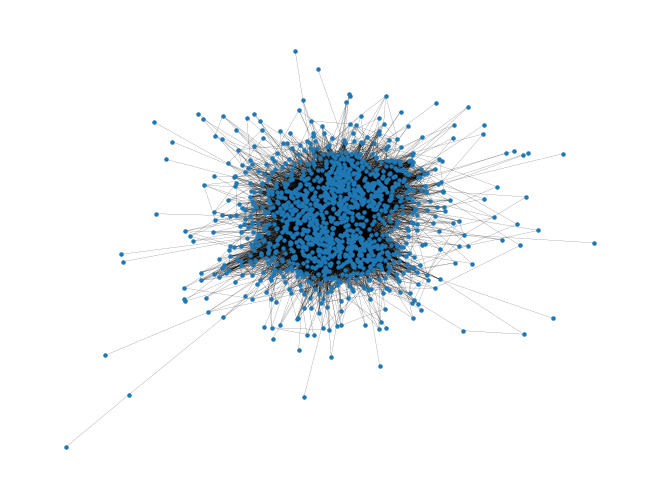

In [26]:
G = nx.from_pandas_edgelist(
    graph_plasma_400,
    source="gene1",
    target="gene2",
    edge_attr="combined_score"
)

largest_cc = max(nx.connected_components(G), key=len)

G_sub = G.subgraph(largest_cc)


nx.draw_spring(
    G_sub,
    node_size=5,
    width=0.1
)

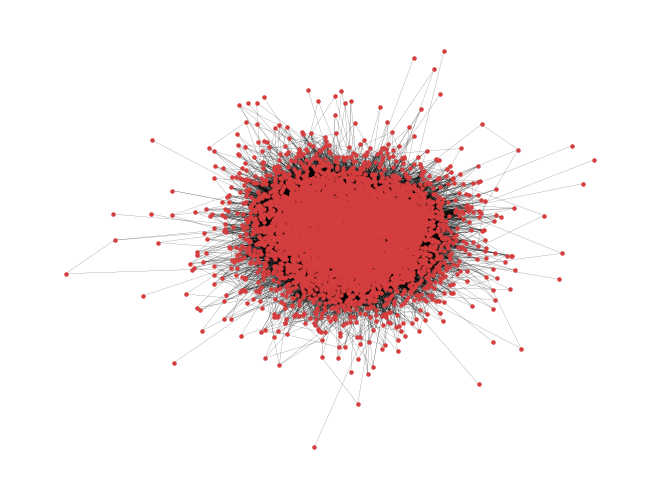

In [37]:
G = nx.from_pandas_edgelist(
    graph_tissue_400,
    source="gene1",
    target="gene2",
    edge_attr="combined_score"
)

largest_cc = max(nx.connected_components(G), key=len)

G_sub = G.subgraph(largest_cc)
color = "#d62728"
nx.draw_spring(
    G_sub,
    node_size=5,
    width=0.1,
    node_color ='#D43D3D' # deep muted red



)

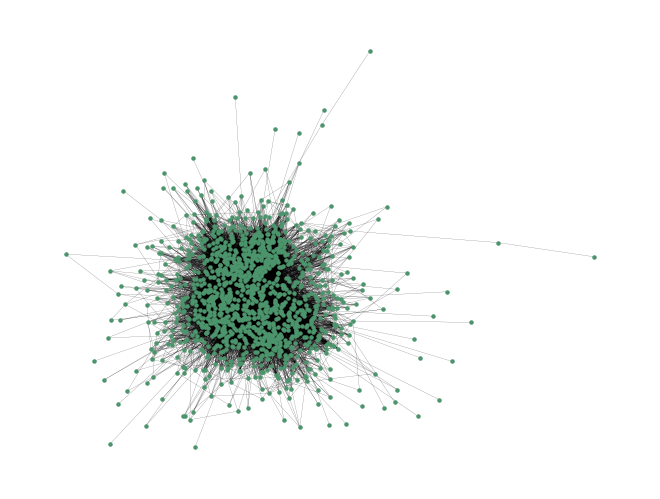

In [38]:
G = nx.from_pandas_edgelist(
    graph_common_400,
    source="gene1",
    target="gene2",
    edge_attr="combined_score"
)

largest_cc = max(nx.connected_components(G), key=len)

G_sub = G.subgraph(largest_cc)
color = '#4C956C'
nx.draw_spring(
    G_sub,
    node_size=5,
    width=0.1,
    node_color=color
)

In [ ]:
from pyvis.network import Network
G400 = nx.from_pandas_edgelist(
    graph_union_400,
    source="gene1",
    target="gene2",
    edge_attr="combined_score"
)
net = Network(
    height="900px",
    width="100%",
    bgcolor="white",
    notebook=True,
    cdn_resources="in_line"
)

for node in G400.nodes():
    net.add_node(node, label=node)


for u,v,data in G400.edges(data=True):
    net.add_edge(
        u,
        v,
        value=data["combined_score"]
    )
net.write_html("protein_graph.html")
